# Design optimisation: annealing a heat sink

The genomics notebook was a fan-in: many samples converging on one result.
This is the opposite shape. An optimiser is a **long chain**, where every step
is a small edit to the one before it, and the interesting object is not any
single design but the trajectory through them.

Chains break the usual tracking approaches. A run directory per iteration
gives you two hundred directories and no memory of which came from which
after a restart. Keeping only the best design throws away the search. Keeping
every design costs real disk, because consecutive iterations are nearly
identical arrays.

The problem here is physical: place cooling fins on a chip to minimise its
peak temperature. Steady-state heat conduction, solved by relaxation, driven
by simulated annealing.

This notebook covers deep chains, branch-and-abandon, `prune` to reclaim the
space, and what delta storage does when consecutive artifacts differ by 1%.

## 1. Setup

In [1]:
import shutil
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ancestree

WORKDIR = Path(tempfile.mkdtemp(prefix="ancestree-optimisation-"))
rng = np.random.default_rng(7)

GRID = 160  # solve on a 160x160 plate
N_FINS = 14
ITERATIONS = 30

## 2. The physics

A square plate with a hot chip in the middle. Fins are high-conductivity
patches that pull heat outward. The solver relaxes the steady-state
temperature field, and the objective is the peak temperature anywhere on the
die.

Nothing here is ancestree specific. It is a stand-in for whatever expensive
function your own optimiser calls.

In [2]:
def conductivity(fins):
    """Conductivity map: baseline substrate, with fins as high-k strips."""
    k = np.full((GRID, GRID), 1.0)
    for x, y, length, vertical in fins:
        if vertical:
            k[y : y + length, x : x + 3] = 12.0
        else:
            k[y : y + 3, x : x + length] = 12.0
    return k


def solve(fins, sweeps=260):
    """Relax the steady-state temperature field. Edges held at ambient."""
    k = conductivity(fins)
    source = np.zeros((GRID, GRID))
    die = slice(GRID // 2 - 12, GRID // 2 + 12)
    source[die, die] = 2.6  # tuned so the die sits in a plausible C range

    temperature = np.zeros((GRID, GRID))
    for _ in range(sweeps):
        neighbours = (
            k[:-2, 1:-1] * temperature[:-2, 1:-1]
            + k[2:, 1:-1] * temperature[2:, 1:-1]
            + k[1:-1, :-2] * temperature[1:-1, :-2]
            + k[1:-1, 2:] * temperature[1:-1, 2:]
        )
        weight = k[:-2, 1:-1] + k[2:, 1:-1] + k[1:-1, :-2] + k[1:-1, 2:]
        temperature[1:-1, 1:-1] = (neighbours + source[1:-1, 1:-1]) / weight
    return temperature, k


def peak_temperature(temperature):
    die = slice(GRID // 2 - 12, GRID // 2 + 12)
    return float(temperature[die, die].max())


def random_layout():
    """Fins start in a band around the die: a fin in the far corner of the
    plate does nothing, and a search full of no-op moves teaches nothing."""
    centre = GRID // 2
    return [
        (
            int(np.clip(centre + rng.integers(-45, 46), 3, GRID - 42)),
            int(np.clip(centre + rng.integers(-45, 46), 3, GRID - 42)),
            int(rng.integers(18, 38)),
            bool(rng.integers(0, 2)),
        )
        for _ in range(N_FINS)
    ]


def perturb(fins):
    """Move one fin. The small edit that makes consecutive designs similar."""
    fins = list(fins)
    i = int(rng.integers(0, len(fins)))
    x, y, length, vertical = fins[i]
    fins[i] = (
        int(np.clip(x + rng.integers(-14, 15), 3, GRID - 42)),
        int(np.clip(y + rng.integers(-14, 15), 3, GRID - 42)),
        int(np.clip(length + rng.integers(-5, 6), 14, 40)),
        vertical if rng.random() > 0.25 else not vertical,
    )
    return fins

## 3. A store for a search

Three step types. `baseline` starts a run, `candidate` follows either the
baseline or another candidate (which is what makes an unbounded chain legal),
and `report` closes one out.

The temperature fields are the interesting artifact: a 160x160 float64 grid
per iteration, where consecutive iterations differ only where a fin moved.
`chunk=True` is the default and is exactly the policy for this, so it is
passed explicitly here to make the point.

In [3]:
store = ancestree.LineageStore(
    WORKDIR / "heatsink",
    rules={
        "baseline": [None],
        "candidate": ["baseline", "candidate"],
        "report": ["candidate"],
    },
    gen_triggers=["baseline"],
    chunk=True,
)


def evaluate(step_type, parent, fins, decide=None, **meta):
    """Solve one design *inside* its node and record the result.

    The solve happens in the block rather than before it, so the node's
    ``duration_s`` measures the work rather than the write. ``decide`` is an
    optional callable taking the objective and returning extra metadata, which
    is how the annealing accept/reject decision gets recorded on the node it
    belongs to.

    Returns (node_id, peak_C, extra_metadata).
    """
    extra = {}
    with store.create_node(step_type=step_type, parent=parent) as node:
        temperature, k = solve(fins)
        peak = peak_temperature(temperature)

        np.save(node / "temperature.npy", temperature)
        np.save(node / "conductivity.npy", k)
        np.save(node / "layout.npy", np.array(fins, dtype=np.int32))

        node.add_meta("peak_C", round(peak, 3), group="Objective")
        node.add_meta("mean_C", round(float(temperature.mean()), 3), group="Objective")
        node.add_meta("fin_count", len(fins), group="Design")
        node.add_meta("fin_area", int(sum(f[2] * 3 for f in fins)), group="Design")

        extra = decide(peak) if decide is not None else {}
        for key, value in {**meta, **extra}.items():
            node.add_meta(key, value, group="Search")
    return node.node_id, peak, extra

## 4. The baseline

An unoptimised layout to beat.

In [4]:
baseline_fins = random_layout()
baseline_id, baseline_peak, _ = evaluate(
    "baseline",
    None,
    baseline_fins,
    optimiser="simulated annealing",
    seed=7,
    iteration=0,
)
print(f"baseline {baseline_id}: peak {baseline_peak:.2f} C")

baseline 939b3925: peak 86.71 C


## 5. The search

Standard annealing: perturb, solve, accept if better or by the Metropolis
criterion, otherwise reject. The solve runs inside the node, so `duration_s`
records what the iteration actually cost.

The lineage decision is the one that matters. **The parent is the accepted
design, not the previous iteration.** A rejected candidate is still recorded,
still holds its field, and is still a real node, but it is a leaf: nothing
descends from it. The chain of parents through the graph is exactly the
sequence of accepted states, so the search path and the search history are
both preserved without either being reconstructed later.

In [5]:
current_fins, current_peak, current_id = baseline_fins, baseline_peak, baseline_id
best_peak, best_id = current_peak, current_id
history = []

for iteration in range(1, ITERATIONS + 1):
    schedule_T = 0.35 * (0.88**iteration)
    proposal = perturb(current_fins)

    def decide(peak, reference=current_peak, anneal_T=schedule_T, step=iteration):
        delta = peak - reference
        return {
            "iteration": step,
            "accepted": bool(
                delta < 0 or rng.random() < np.exp(-delta / max(anneal_T, 1e-9))
            ),
            "delta_C": round(delta, 3),
            "anneal_T": round(anneal_T, 4),
        }

    node_id, peak, outcome = evaluate("candidate", current_id, proposal, decide=decide)
    accepted = outcome["accepted"]

    if accepted:
        current_fins, current_peak, current_id = proposal, peak, node_id
        if peak < best_peak:
            best_peak, best_id = peak, node_id

    history.append(
        {
            "iteration": iteration,
            "peak_C": peak,
            "accepted": accepted,
            "best_so_far": best_peak,
        }
    )

trace = pd.DataFrame(history)
print(f"{trace['accepted'].sum()} of {ITERATIONS} proposals accepted")
print(
    f"peak temperature {baseline_peak:.2f} C -> {best_peak:.2f} C "
    f"({(1 - best_peak / baseline_peak):.1%} better)"
)

25 of 30 proposals accepted
peak temperature 86.71 C -> 57.57 C (33.6% better)


## 6. What the chain cost to store

Thirty-one temperature fields, thirty-one conductivity maps, each one a small
edit away from its predecessor. Content-defined boundaries survive a local
edit, so the chunks away from the moved fin are byte-identical to ones already
in the pool and are stored once. The chunks that did change are checked
against what they resemble and kept as deltas when that wins.

Read the encoding counts below with that order in mind: exact chunk dedup does
most of the work on a workload like this, and delta storage picks up the
remainder that exact matching cannot.

In [6]:
stats = store.stats()
kinds = {
    row["kind"]: row["n"]
    for row in store.sql("SELECT kind, count(*) AS n FROM chunk GROUP BY kind")
}
print(f"  nodes                {stats['nodes']:>10}")
print(f"  artifacts            {stats['artifacts']:>10}")
print(f"  logical bytes        {stats['logical_bytes'] / 1e6:>10.2f} MB")
print(f"  stored in the pool   {stats['chunk_stored_bytes'] / 1e6:>10.2f} MB")
print(f"  database on disk     {stats['database_bytes'] / 1e6:>10.2f} MB")
print(f"  dedup ratio          {stats['dedup_ratio']:>10}x")
print(
    f"\n  chunk encodings:  zlib {kinds.get(0, 0)}   "
    f"delta {kinds.get(1, 0)}   verbatim {kinds.get(2, 0)}"
)

  nodes                        31
  artifacts                    93
  logical bytes             12.72 MB
  stored in the pool         5.81 MB
  database on disk          10.90 MB
  dedup ratio               2.188x

  chunk encodings:  zlib 381   delta 14   verbatim 0


## 7. Reading the search back

### The accepted trajectory

`lineage()` returns a node's full ancestry plus itself, oldest first. Applied
to the best design, that *is* the accepted path: every node the search moved
through to get there, and nothing it rejected.

In [7]:
path = store.lineage(best_id)
print(f"{len(path)} nodes from baseline to best\n")
print(f"  {'step':<10} {'iter':>5} {'peak_C':>9} {'delta_C':>9}")
for node in path:
    meta = node.metadata
    print(
        f"  {node.step_type:<10} {meta['iteration']['value']:>5} "
        f"{meta['peak_C']['value']:>9.2f} "
        f"{meta.get('delta_C', {}).get('value', 0):>9}"
    )

25 nodes from baseline to best

  step        iter    peak_C   delta_C
  baseline       0     86.71         0
  candidate      1     86.71       0.0
  candidate      2     86.67    -0.043
  candidate      4     86.39    -0.281
  candidate      5     86.39       0.0
  candidate      6     86.39     0.003
  candidate      8     86.39      -0.0
  candidate      9     86.39      -0.0
  candidate     10     86.39       0.0
  candidate     11     81.14    -5.245
  candidate     12     81.14      -0.0
  candidate     13     81.14      -0.0
  candidate     14     81.14       0.0
  candidate     15     81.14       0.0
  candidate     16     57.70    -23.45
  candidate     17     57.70       0.0
  candidate     18     57.70       0.0
  candidate     20     57.70      -0.0
  candidate     21     57.58     -0.12
  candidate     23     57.58       0.0
  candidate     25     57.58       0.0
  candidate     26     57.58       0.0
  candidate     27     57.58       0.0
  candidate     28     57.57    

### Everything, accepted or not

`find()` sees the whole search. Filters match structural attributes and
searchable metadata in one namespace, so `step_type` and `accepted` compose.

In [8]:
evaluated = store.find(step_type="candidate")
rejected = store.find(step_type="candidate", accepted=False)
improvements = store.find(
    step_type="candidate", delta_C=lambda d: d is not None and d < 0
)
uphill = store.find(
    step_type="candidate", accepted=True, delta_C=lambda d: d is not None and d > 0
)
neutral = store.find(
    step_type="candidate", accepted=True, delta_C=lambda d: d is not None and d == 0
)

print(f"  designs evaluated        {len(evaluated)}")
print(f"  rejected (leaf nodes)    {len(rejected)}")
print(f"  strict improvements      {len(improvements)}")
print(f"  uphill moves accepted    {len(uphill)}")
print(f"  neutral moves accepted   {len(neutral)}")

  designs evaluated        30
  rejected (leaf nodes)    5
  strict improvements      6
  uphill moves accepted    1
  neutral moves accepted   18


The uphill count is the one worth being able to ask for. Annealing is
*supposed* to accept some worse designs early on, and counting them after the
fact is how you tell a working schedule from a broken one.

The neutral count is the other half of the story, and it is a finding about
the *search*, not the store: a fin moved far from the die changes the peak by
nothing at all, so a large share of the proposal distribution is wasted. That
is a reason to fix the proposal, and it is only visible because every
rejected and neutral design was kept.

### The best designs, ranked

A predicate receives the stored value, or `None` when a node has no such key.
The `is not None` guard is not defensive style, it is required: the baseline
and report nodes have no `delta_C`.

In [9]:
good = store.find(peak_C=lambda p: p is not None and p < baseline_peak * 0.97)
ranked = sorted(good, key=lambda n: n.metadata["peak_C"]["value"])

print(f"{len(good)} designs at least 3% better than baseline\n")
for node in ranked[:5]:
    meta = node.metadata
    print(
        f"  {node.node_id}  iter {meta['iteration']['value']:>3}  "
        f"peak {meta['peak_C']['value']:>7.2f} C  "
        f"fin_area {meta['fin_area']['value']}"
    )

18 designs at least 3% better than baseline

  ca6a2de6  iter  28  peak   57.57 C  fin_area 1197
  a8e9c2a4  iter  29  peak   57.57 C  fin_area 1212
  ee5abf3f  iter  30  peak   57.57 C  fin_area 1203
  b5cca966  iter  21  peak   57.58 C  fin_area 1179
  314bf517  iter  23  peak   57.58 C  fin_area 1185


### Resuming

`latest()` is how a restarted script picks up where it stopped, without a
checkpoint file to keep in sync with the store.

In [10]:
resume = store.latest(step_type="candidate", accepted=True)
print(
    f"most recent accepted design: {resume.node_id} "
    f"(iteration {resume.metadata['iteration']['value']}, "
    f"peak {resume.metadata['peak_C']['value']:.2f} C)"
)
print(f"its layout: {[p.name for p in resume.artifacts('layout*')]}")
print(f"children:   {len(store.children(resume))}")

most recent accepted design: ee5abf3f (iteration 30, peak 57.57 C)
its layout: ['layout.npy']
children:   0


## 8. A branch that did not work out

Real searches fork. Here a second strategy starts from the same baseline:
fewer, longer fins. It is explored for a few iterations and abandoned.

In [11]:
def long_fin_layout():
    centre = GRID // 2
    return [
        (
            int(np.clip(centre + rng.integers(-45, 46), 3, GRID - 45)),
            int(np.clip(centre + rng.integers(-45, 46), 3, GRID - 45)),
            int(rng.integers(34, 40)),
            bool(rng.integers(0, 2)),
        )
        for _ in range(N_FINS // 2)
    ]


branch_fins = long_fin_layout()
branch_root, branch_peak, _ = evaluate(
    "candidate",
    baseline_id,
    branch_fins,
    iteration=101,
    accepted=True,
    strategy="few long fins",
    delta_C=0.0,
)

branch_current = branch_fins
branch_tip = branch_root
for iteration in range(102, 108):
    proposal = perturb(branch_current)

    def decide(peak, reference=branch_peak, step=iteration):
        return {
            "iteration": step,
            "accepted": True,
            "delta_C": round(peak - reference, 3),
            "strategy": "few long fins",
        }

    branch_tip, branch_peak, _ = evaluate(
        "candidate", branch_tip, proposal, decide=decide
    )
    branch_current = proposal

print(f"branch best {branch_peak:.2f} C against main line {best_peak:.2f} C")
print(
    f"the branch is {'worse' if branch_peak > best_peak else 'better'}, so abandon it"
)

branch best 110.16 C against main line 57.57 C
the branch is worse, so abandon it


### Preview the deletion first

`prune` defaults to a dry run. It returns the nodes that *would* go and
changes nothing. The rule is that a descendant dies only when every one of its
parents is dying, so pruning a branch root cannot reach across a join and take
something still in use.

In [12]:
doomed = store.prune(branch_root)
print(f"prune(branch_root) would delete {len(doomed)} nodes:\n")
for node in doomed:
    print(
        f"  {node.node_id}  iter {node.metadata['iteration']['value']}  "
        f"peak {node.metadata['peak_C']['value']:.2f} C"
    )

print(f"\nstore unchanged: {store.stats()['nodes']} nodes")

prune(branch_root) would delete 7 nodes:

  095a5318  iter 107  peak 110.16 C
  070e0afa  iter 106  peak 110.16 C
  ff13083e  iter 105  peak 110.17 C
  aeea673d  iter 104  peak 110.27 C
  0b70a261  iter 103  peak 110.27 C
  78edcafc  iter 102  peak 110.27 C
  a5da3475  iter 101  peak 110.27 C

store unchanged: 38 nodes


### Then commit to it

`dry_run=False` deletes and then compacts: chunks nothing references are
dropped and the database file shrinks in place. There is no undo.

In [13]:
before = store.stats()
deleted = store.prune(branch_root, dry_run=False)
after = store.stats()

print(f"  deleted            {len(deleted)} nodes")
print(f"  nodes      {before['nodes']:>8} -> {after['nodes']}")
print(f"  chunks     {before['chunks']:>8} -> {after['chunks']}")
print(
    f"  pool MB    {before['chunk_stored_bytes'] / 1e6:>8.2f} -> "
    f"{after['chunk_stored_bytes'] / 1e6:.2f}"
)
print(
    f"  file MB    {before['database_bytes'] / 1e6:>8.2f} -> "
    f"{after['database_bytes'] / 1e6:.2f}"
)
print(f"\n  main line intact: {len(store.lineage(best_id))} nodes to the best design")

  deleted            7 nodes
  nodes            38 -> 31
  chunks          488 -> 395
  pool MB        7.15 -> 5.81
  file MB       10.90 -> 6.66

  main line intact: 25 nodes to the best design


Pruning in a loop should pass `compact=False` and call `store.compact()` once
at the end. Compaction scans the whole chunk pool, so doing it per node is
wasted work:

```python
for dead_branch in abandoned:
    store.prune(dead_branch, dry_run=False, compact=False)
store.compact()
```

In [14]:
print(f"compact() on an already-compact store freed {store.compact()} chunks")

compact() on an already-compact store freed 0 chunks


## 9. The report

A closing node holding the convergence plot, the winning field, and the
summary table. A `Path` handed to `add_meta` is recognised as an image by its
suffix and rendered inline in the explorer, so the figures travel with the
result.

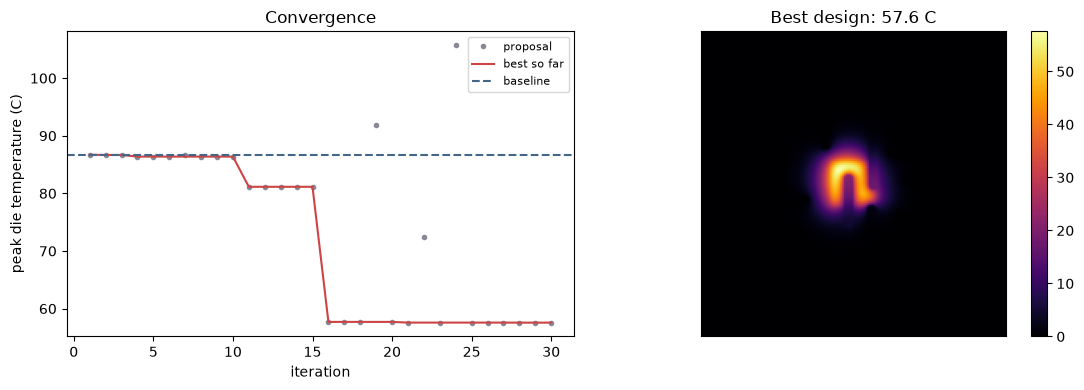

report 3c13a193


In [15]:
best = store.get(best_id)
best_field = np.load(best / "temperature.npy")
best_layout = np.load(best / "layout.npy")

with store.create_node(step_type="report", parent=best_id) as node:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(trace["iteration"], trace["peak_C"], ".", color="#889", label="proposal")
    ax1.plot(
        trace["iteration"], trace["best_so_far"], "-", color="#c44", label="best so far"
    )
    ax1.axhline(baseline_peak, color="#468", ls="--", label="baseline")
    ax1.set_xlabel("iteration")
    ax1.set_ylabel("peak die temperature (C)")
    ax1.set_title("Convergence")
    ax1.legend(fontsize=8)

    im = ax2.imshow(best_field, cmap="inferno")
    ax2.set_title(f"Best design: {best_peak:.1f} C")
    ax2.set_xticks([])
    ax2.set_yticks([])
    fig.colorbar(im, ax=ax2, fraction=0.046)
    fig.tight_layout()
    fig.savefig(node / "convergence.png", dpi=110)
    plt.show()

    trace.to_csv(node / "search_trace.csv", index=False)
    np.save(node / "best_layout.npy", best_layout)

    node.add_meta("baseline_peak_C", round(baseline_peak, 3), group="Result")
    node.add_meta("best_peak_C", round(best_peak, 3), group="Result")
    node.add_meta("improvement", f"{1 - best_peak / baseline_peak:.1%}", group="Result")
    node.add_meta("designs_evaluated", len(evaluated), group="Result")
    node.add_meta("best_design_node", best_id, group="Result")
    node.add_meta(
        "figures", node / "convergence.png", group="Result", data_type="image"
    )
    node.add_meta("last_10", trace.tail(10), group="Result", data_type="table")
    node.add_meta(
        "schedule",
        {"kind": "geometric", "T0": 0.35, "alpha": 0.88, "iterations": ITERATIONS},
        group="Result",
        data_type="json",
    )

report_id = node.node_id
print(f"report {report_id}")

## 10. Cost of the search, from the store itself

`duration_s` is recorded on every node without being asked for, so the store
can answer where the wall time went. In an optimisation that is normally the
solver, and knowing the ratio tells you whether to buy a faster solver or a
smarter proposal distribution.

In [16]:
rows = store.sql(
    """
    SELECT step_type,
           count(*)                          AS nodes,
           round(sum(duration_s), 2)         AS total_s,
           round(avg(duration_s) * 1000, 1)  AS mean_ms,
           round(sum(size_bytes) / 1e6, 2)   AS artifact_MB
    FROM node
    GROUP BY step_type
    ORDER BY total_s DESC
    """
)
print(pd.DataFrame([dict(r) for r in rows]).to_string(index=False))

step_type  nodes  total_s  mean_ms  artifact_MB
candidate     30     1.06     35.5        12.31
   report      1     0.14    144.0         0.05
 baseline      1     0.03     33.0         0.41


And the accept/reject behaviour across the three phases of the schedule. The
raw acceptance rate is uninformative here because so many proposals are
neutral and a neutral move is always accepted, so the query separates them
out. What to read is `uphill_accepted` against `uphill`: the schedule should
tolerate worse designs early and stop tolerating them late.

In [17]:
rows = store.sql(
    """
    SELECT (CAST(i.value AS INT) - 1) / 10                       AS phase,
           round(avg(CAST(t.value AS REAL)), 3)                  AS mean_anneal_T,
           count(*)                                              AS proposals,
           sum(CAST(d.value AS REAL) = 0)                        AS neutral,
           sum(CAST(d.value AS REAL) > 0)                        AS uphill,
           sum(CAST(d.value AS REAL) > 0
               AND json_extract(a.value, '$') = 1)               AS uphill_accepted
    FROM metadata i
    JOIN metadata a ON a.node_id = i.node_id AND a.key = 'accepted'
    JOIN metadata t ON t.node_id = i.node_id AND t.key = 'anneal_T'
    JOIN metadata d ON d.node_id = i.node_id AND d.key = 'delta_C'
    WHERE i.key = 'iteration' AND CAST(i.value AS INT) BETWEEN 1 AND 30
    GROUP BY phase
    ORDER BY phase
    """
)
print(pd.DataFrame([dict(r) for r in rows]).to_string(index=False))

 phase  mean_anneal_T  proposals  neutral  uphill  uphill_accepted
     0          0.185         10        5       3                1
     1          0.052         10        7       1                0
     2          0.014         10        6       2                0


## 11. Handing it over

In [18]:
graph = store.generate_web_graph()
print(f"web graph  {graph.name}  ({graph.stat().st_size / 1024:.0f} KiB)")

backup = store.backup(WORKDIR / "heatsink_backup")
print(f"backup     {backup.parent.name}/{backup.name}")

final = store.stats()
print(
    f"\nfinal store: {final['nodes']} nodes, "
    f"{final['logical_bytes'] / 1e6:.1f} MB of fields stored in "
    f"{final['database_bytes'] / 1e6:.1f} MB on disk "
    f"({final['dedup_ratio']}x)"
)

web graph  interactive_pipeline.html  (591 KiB)
backup     heatsink_backup/ancestree.db

final store: 32 nodes, 12.8 MB of fields stored in 6.9 MB on disk (2.178x)


The live explorer is the better tool for a search this shape, because the
chain is long and you want to scrub along it rather than click through it:

```python
store.host_live_graph()          # searchable explorer on localhost
```

It takes `field=value`, numeric filters like `peak_C<75`, and free text; you
can pin two designs for a side-by-side diff, or sort the runs table by any
column. From a notebook it returns immediately and serves in the background
until the store closes.

## What this bought

- Thirty-eight designs kept in full, at a fraction of their logical size,
  because consecutive fields differ by one fin.
- The accepted trajectory recoverable with `lineage()`, and the rejected
  proposals still present as leaves rather than discarded.
- Uphill moves countable after the fact, which is the difference between
  trusting an annealing schedule and checking it.
- An abandoned branch previewed, deleted, and its space genuinely reclaimed.

In [ ]:
# store.close()
# shutil.rmtree(WORKDIR, ignore_errors=True)
store.host_live_graph()